# Half-Life For Mean Reversion

The $\text{AR}(1)$ process with constant offset is defined by,

$
\begin{align}
X_t = \varphi X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{1}
$

where $\varepsilon_t \sim \text{Normal}(0, 1)$. Subtracting $X_{t-1}$ from both sides gives,

$
\begin{align}
\Delta X_t = \left(\varphi - 1 \right) X_{t-1}\Delta t + \mu\Delta t + \sigma\sqrt{\Delta t}\hspace{2pt} \varepsilon_t
\end{align}
\tag{2}
$

This can be reparameterized to,

$
\begin{align}
\Delta X_t = \lambda \left(\frac{\mu}{\lambda} + X_{t-1}\right)\Delta t + \sigma\sqrt{\Delta t}\hspace{2pt} \varepsilon_t
\end{align}
\tag{3}
$

where $\lambda = \varphi - 1$.

The continuous differential form of this equation is the Ornstein-Uhlenbeck SDE,

$
\begin{align}
dX_t = \lambda \left(\frac{\mu}{\lambda} + X_t \right) dt + \sigma dB_t
\end{align}
\tag{4}
$

where $dB_t \sim \text{Normal}(0, dt)$. The Ornstein-Uhlenbeck SDE models a mean reverting random process and can be solved using the integration factor, $e^{-\lambda t}$

$
\begin{align}
X_t = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right) + \sigma \int_0^t e^{\lambda\left( t - s \right)} dB_s
\end{align}
\tag{5}
$

The mean value is given by,

$
\begin{align}
\text{E}\left[ X_t \right] = X_0 e^{\lambda t} + \frac{\mu}{\lambda} \left( 1 - e^{\lambda t} \right)
\end{align}
\tag{6}
$

For the limit $t \to \infty$ a finite mean value requires $\lambda < 0$,

$
\begin{align}
\text{E}\left[ X_t \right] = -\frac{\mu}{\lambda}
\end{align}
\tag{7}
$

The half life of mean decay is the time to reach $\frac{1}{2}$ the $t \to \infty$ value from the initial value. This defines the timescale of the Ornstein-Uhlenbeck process. If $t_H$ denotes the half life. It follows that $X_{t_H}$ is given by,

$
\begin{align}
X_{t_H} = X_0 - \frac{1}{2}\left(\frac{\mu}{\lambda} + X_0 \right)
\end{align}
\tag{8}
$

Using $Eq(7)$ and $Eq(8)$ and solving for $t_H$ gives,

$
\begin{align}
t_H = -\frac{\ln{2}}{\lambda}
\end{align}
\tag{9}
$

$\lambda$ can be evaluated by using regression on the equation,

$
\begin{align}
\Delta X_t = \lambda X_{t-1} + \mu + \sigma \varepsilon_t
\end{align}
\tag{10}
$



In [1]:
%reload_ext autoreload
%autoreload 2

# import system modules and set local import path
import os
import sys
import numpy
from matplotlib import pyplot

sys.path.insert(0, os.path.abspath('../../..'))

# import local modules
from lib import config
from lib.data import ou, stats
from lib.plots import comparison, stack, curve, fbar, scatter, mean_reversion_halflife
from lib.utils import create_ensemble, create_parameter_scan

# Config Plot Style
pyplot.style.use(config.glyfish_style)

## Zero Mean

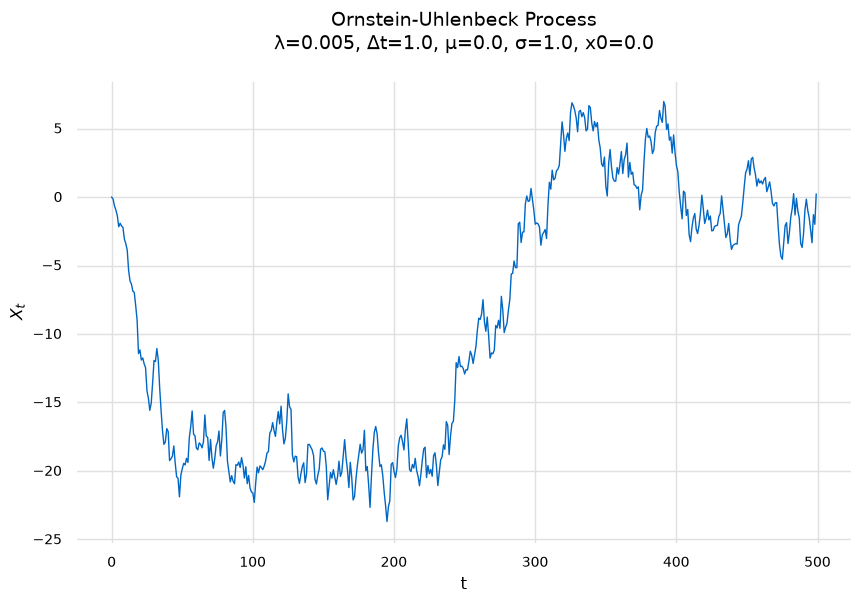

In [2]:
λ = 0.005
Δt = 1.0
μ = 0.0
σ = 1.0
x0 = 0.0
npts = 500
params = {"μ": μ, "λ": λ, "σ": σ, "x0": x0, "npts": npts, "Δt": Δt}
title = f"Ornstein-Uhlenbeck Process\nλ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
t, xt = ou.create_source(**params)
curve(xt, t, title=title, xlabel="t", ylabel=r"$X_t$", lw=1)

In [3]:
result, result_model = ou.compute_mean_half_life_estimate(xt, Δt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.003
Model:                            OLS   Adj. R-squared:                  0.001
Method:                 Least Squares   F-statistic:                     1.421
Date:                Sun, 30 Aug 2026   Prob (F-statistic):              0.234
Time:                        11:57:46   Log-Likelihood:                -719.38
No. Observations:                 499   AIC:                             1443.
Df Residuals:                     497   BIC:                             1451.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         -0.0513      0.063     -0.812      0.417      -0.175       0.073
x1            -0.0057      0.005     -1.192      0.234      -0.015       0.004
==============================================================================
Omnibus:                        0.016   Durbin-Watson:                   1.867
Prob(Omnibus):                  0.992   Jarque-Bera (JB):                0.013
Skew:                           0.010   Prob(JB):                        0.994
Kurtosis:                       2.985   Cond. No.                         18.1
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [4]:
print(result_model.to_json(True))

{
   "est_model": "OLS",
   "const": {
      "est": -0.051334266541104887,
      "err": 0.06318585850673959,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "b1a9c028-9045-444c-b964-9b4c20bd4bc5",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.005746092804621858,
         "err": 0.004820475799091407,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "b1a9c028-9045-444c-b964-9b4c20bd4bc5",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.0028508161315692337,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "b1a9c028-9045-444c-b964-9b4c20bd4bc5",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "

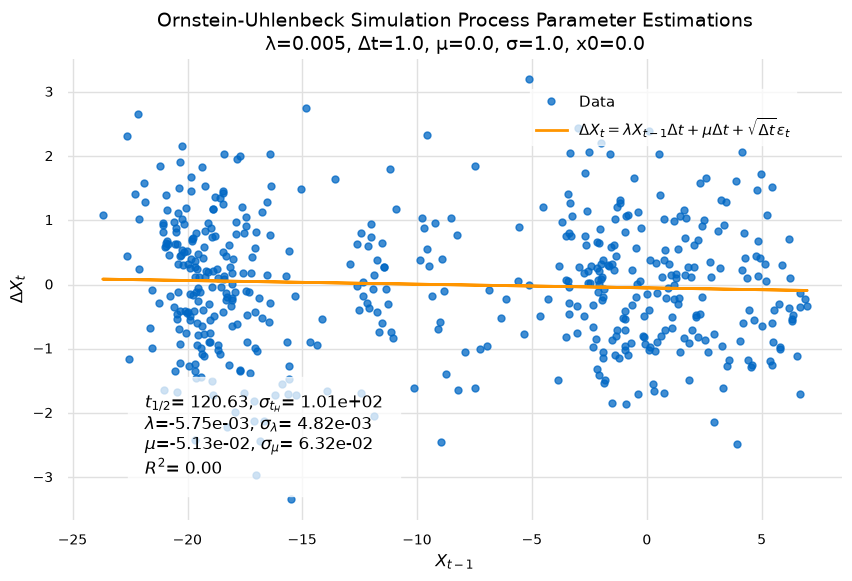

In [5]:
title = f"Ornstein-Uhlenbeck Simulation Process Parameter Estimations\nλ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
mean_reversion_halflife(xt, result_model, title=title)

## Nonezero Mean

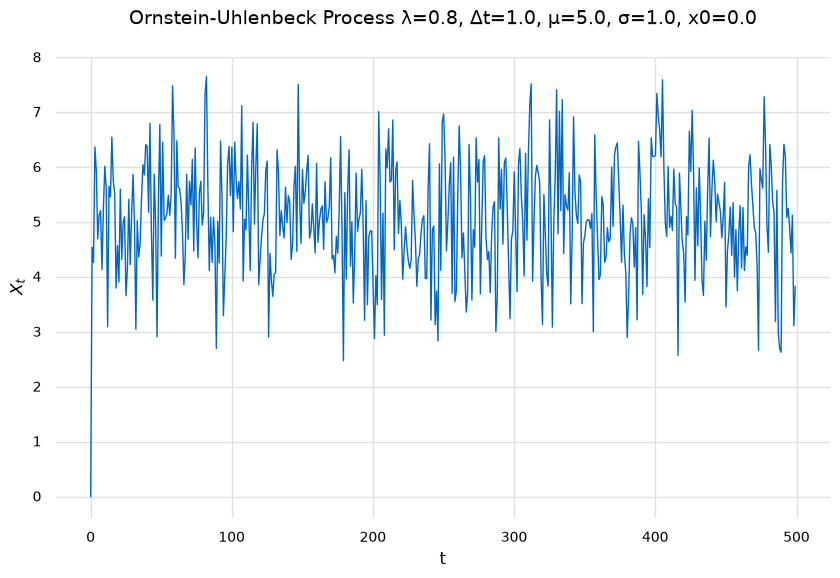

In [6]:
λ = 0.8
Δt = 1.0
μ = 5.0
σ = 1.0
x0 = 0.0
npts = 500
params = {"μ": μ, "λ": λ, "σ": σ, "x0": x0, "npts": npts, "Δt": Δt}
title = f"Ornstein-Uhlenbeck Process λ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
t, xt = ou.create_source(**params)
curve(xt, t, title=title, xlabel="t", ylabel=r"$X_t$", lw=1)

In [7]:
result, result_model = ou.compute_mean_half_life_estimate(xt, Δt)
result.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                      y   R-squared:                       0.422
Model:                            OLS   Adj. R-squared:                  0.421
Method:                 Least Squares   F-statistic:                     362.6
Date:                Sun, 30 Aug 2026   Prob (F-statistic):           4.05e-61
Time:                        11:57:46   Log-Likelihood:                -705.98
No. Observations:                 499   AIC:                             1416.
Df Residuals:                     497   BIC:                             1424.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          4.1764      0.223     18.693      0.000       3.737       4.615
x1            -0.8204      0.043    -19.043      0.000      -0.905      -0.736
==============================================================================
Omnibus:                        2.057   Durbin-Watson:                   1.999
Prob(Omnibus):                  0.358   Jarque-Bera (JB):                1.980
Skew:                          -0.090   Prob(JB):                        0.372
Kurtosis:                       2.749   Cond. No.                         26.9
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [8]:
print(result_model.to_json(True))

{
   "est_model": "OLS",
   "const": {
      "est": 4.176403467681361,
      "err": 0.2234243661461922,
      "est_label": "$\\beta$",
      "err_label": "$\\sigma_{\\beta}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "9265e89e-9116-43a2-9266-be91274a0be8",
      "param_type": "OLS_CONST"
   },
   "params": [
      {
         "est": -0.8204171589473868,
         "err": 0.04308268858581673,
         "est_label": "$\\alpha_1$",
         "err_label": "$\\sigma_{\\alpha_1}$",
         "row": 0,
         "column": 1,
         "order": 0,
         "est_id": "9265e89e-9116-43a2-9266-be91274a0be8",
         "param_type": "OLS_PARAM"
      }
   ],
   "r2": {
      "est": 0.42184436305444917,
      "err": 0.0,
      "est_label": "$R^2$",
      "err_label": "$\\sigma_{R^2}$",
      "row": 0,
      "column": 0,
      "order": 0,
      "est_id": "9265e89e-9116-43a2-9266-be91274a0be8",
      "param_type": "OLS_R2"
   },
   "param_transforms": [
      {
         "param": {


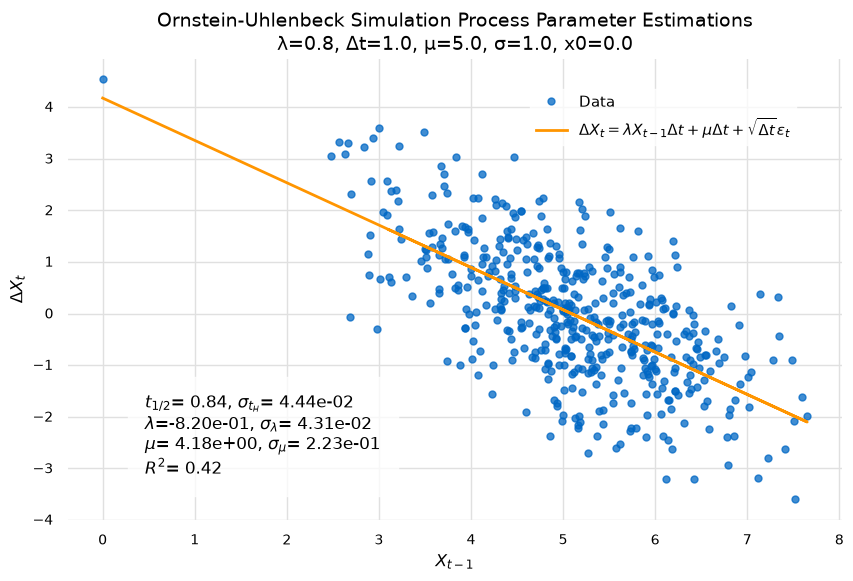

In [9]:
title = f"Ornstein-Uhlenbeck Simulation Process Parameter Estimations\nλ={λ}, Δt={Δt}, μ={μ}, σ={σ}, x0={x0}"
mean_reversion_halflife(xt, result_model, title=title)